In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json
import numpy as np
import pandas as pd
import time
import scipy

In [4]:
def plot_naive(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]

	# plot
	plt.figure(figsize=(25, 6))
	plt.plot(x, y)
	plt.title(f"Signal: $G(x) = \\cos(2\\pi \\cdot 3x)$")
	plt.xlabel("Time (s)")
	plt.grid(True)
	plt.show()

In [5]:
def plot_2D(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]
		Gxy = [item['z'] for item in data]

		# plot
		fig = plt.figure(figsize=(12, 8))
		ax = fig.add_subplot(111, projection='3d')

		# Plot the surface
		surf = ax.plot_surface(np.array(x).reshape((int(np.sqrt(len(x))), int(np.sqrt(len(x))))),
						 	   np.array(y).reshape((int(np.sqrt(len(y))), int(np.sqrt(len(y))))),
							   np.array(Gxy).reshape((int(np.sqrt(len(Gxy))), int(np.sqrt(len(Gxy))))),
							   cmap="PiYG", antialiased=True, shade=True)

		# Add labels and formatting
		ax.set_title('$G(x, y) = \\cos(2\\pi f_x x) \\cos(2\\pi f_y y)$')
		ax.set_xlabel('x')
		ax.set_ylabel('y')
		ax.set_zlabel('G(x, y)')
		fig.colorbar(surf, shrink=0.5, aspect=10)
		plt.show()

In [7]:
#plot_2D('Gxy_vs_xy.json')   ### this image was generated with N=128 and fx, fy=2

In [8]:
def plot_fft(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['abs'] for item in data]

		plt.stem(range(len(x)), y) # Plot positive frequencies
		plt.title("FFT Magnitude Spectrum")
		plt.xlabel("Frequency (Hz)")
		plt.ylabel("|X(k)|")
		plt.grid(True)
		plt.show()

In [9]:
def plot_fft_2D(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]
		z = [item['z'] for item in data]

		fig = plt.figure(figsize=(12, 8))
		ax = fig.add_subplot(111, projection='3d')

		# Draw the 'heads' of the stems
		ax.scatter(x, y, z, color='blue', s=30, label='FFT Peaks')

		# Draw the 'stems' (lines from the floor to the peak)
		for xi, yi, zi in zip(x, y, z):
		    ax.plot([xi, xi], [yi, yi], [0, zi], color='black', alpha=0.6, linewidth=1)

		# Formatting
		ax.set_title("3D Stem Plot of 2D FFT ($X_{kl}$)")
		ax.set_xlabel('Frequency $f_x$')
		ax.set_ylabel('Frequency $f_y$')
		ax.set_zlabel('Magnitude')
		ax.view_init(elev=25, azim=50)

		plt.tight_layout()
		plt.show()


In [10]:
#plot_fft_2D('fft_prova.json')

In [18]:
def plot_benchmark_serial(file1, file2):
	try:
		df1 = pd.read_csv(file1)
		df2 = pd.read_csv(file2)
	except Exception as e:
		print(f"Error reading file: {e}")
		return

	x = np.arange(64, 4096)

	def model(x, a):
		return a * x**2 * np.log(x)

	a1, _ = scipy.optimize.curve_fit(model, df1['N'], df1['ExecutionTime'])
	a2, _ = scipy.optimize.curve_fit(model, df2['N'], df2['ExecutionTime'])

	# 2. Create the visualization
	plt.figure(figsize=(10, 6))
	plt.scatter(df1['N'], df1['ExecutionTime'], 
			marker='s',
			color='#e74c3c', 
			label='iterative FFT serial',
			zorder=1)
	plt.scatter(df2['N'], df2['ExecutionTime'], 
			marker='s',
			color="#00c20a", 
			label='ditfft2 FFT serial',
			zorder=2)
	plt.plot(x, a2*x*x*np.log(x), 
			linestyle='--',        # Solid line
			color="#001eff",      # Red color
			linewidth=1, 
			label='$\\mathcal{O}(N^2\\log N)$',
			zorder=1)
	plt.plot(x, a1*x*x*np.log(x), 
			linestyle='--',        # Solid line
			color="#ff8000",      # Red color
			linewidth=1, 
			label='$\\mathcal{O}(N^2\\log N)$',
			zorder=1)

	

	# 3. Add labels and styling
	plt.title('Algorithm Performance Analysis', fontsize=14)
	plt.xlabel('Matrix Size (N)', fontsize=12)
	plt.ylabel('Execution Time (seconds)', fontsize=12)
	plt.xscale('log', base=2)
	plt.grid(True, linestyle='--', alpha=0.7)
	plt.legend()

	# 4. Show the result	
	plt.show()

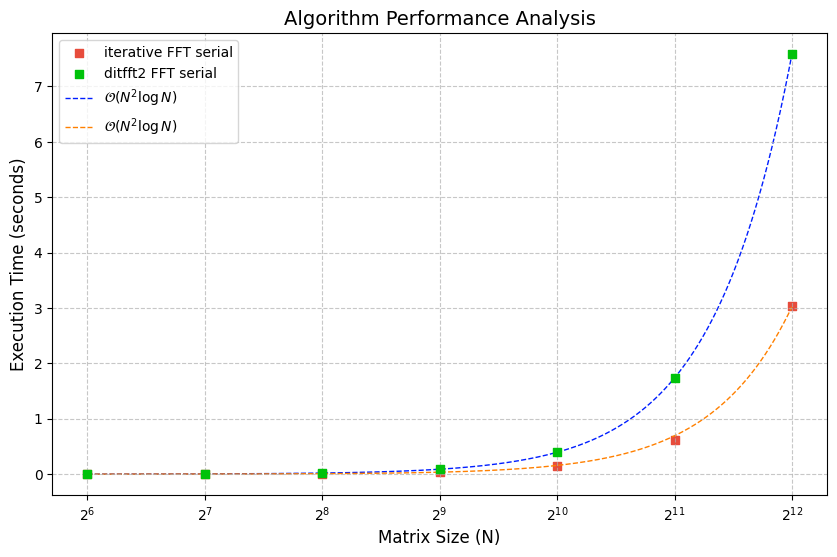

In [19]:
plot_benchmark_serial("results.csv", 'results_ditfft2.csv')

## using bit-reversal and precomputation of twiddle takes half of the time

In [13]:
def bit_reverse(N, x):
    y = 0
    for i in range(N-1):
        y = (y << 1) | (x & 1)
        x >>= 1
